## 04 — Fusion Model: Knowledge Distillation

Builds the multimodal fusion model by incorporating eye-tracking clinical 
knowledge into the facial image classifier through class-conditional knowledge 
distillation.

The two datasets come from different participant populations (confirmed by client). 
This rules out standard late fusion and intermediate fusion, which require matched 
participants. Knowledge distillation is the principled solution — the eye-tracking 
SVM acts as a teacher during face model training, encoding its clinical knowledge 
permanently into the face model's weights.

At inference, only a facial photograph is needed.

## Architecture
```
TRAINING
─────────
Facial images ──→ EfficientNet-B0 ──→ Combined Loss ←── Eye-tracking SVM targets
                                      (60% CrossEntropy + 40% Distillation)

INFERENCE
─────────
Facial photograph ──→ EfficientNet-B0 (distillation-enriched) ──→ ASD risk score
```

**Unimodal baselines to beat:**

| Modality | Accuracy | ASD Recall | ASD F1 |
|---|---|---|---|
| Face only (Notebook 02) | 86.00% | 0.830 | 0.800 |
| Eye-tracking only (Notebook 03) | 82.60% | 0.880 | 0.827 |

In [ ]:
# Imports and Configuration 
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import wandb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from PIL import Image

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report
)

import joblib
import wandb



# Reproducibility 
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)


# Device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


# Connect to Google Drive and load data/model
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Paths 
MY_DRIVE  = '/content/drive/MyDrive'  # TODO: update to relative path
BASE_PATH = f'{MY_DRIVE}/Dataset'        # TODO: update to relative path
FACE_PATH = f'{BASE_PATH}/autism_dataset/images'

# Distillation Hyperparameters 
TEMPERATURE = 2.0   # softens probability distributions for distillation loss
ALPHA       = 0.4   # weight of distillation loss (1-ALPHA = CE loss weight)


# Training Hyperparameters 
LEARNING_RATE          = 1e-4
BATCH_SIZE             = 32
NUM_EPOCHS             = 30
EARLY_STOPPING_PATIENCE = 5
IMG_SIZE               = 224

# Output paths
FUSION_MODEL_PATH    = f'{MY_DRIVE}/best_fusion_model.pth'
FUSION_HISTORY_PATH  = f'{MY_DRIVE}/fusion_training_history.csv'
FUSION_RESULTS_PATH  = f'{MY_DRIVE}/fusion_results.png'

print("Imports and configuration complete")
print(f"   ALPHA={ALPHA} | TEMPERATURE={TEMPERATURE} | LR={LEARNING_RATE}")
print(f"   Batch size={BATCH_SIZE} | Max epochs={NUM_EPOCHS}")

Imports and configuration complete
   ALPHA=0.4 | TEMPERATURE=2.0 | LR=0.0001
   Batch size=32 | Max epochs=30


In [42]:
# Environment Verification and Data Loading

# Verify GPU
print(f"Device: {device}")
assert str(device) == 'cuda:0' or 'cuda' in str(device), "GPU not available - check runtime"

# Load face dataset manifest
manifest = pd.read_csv(f'{MY_DRIVE}/face_dataset_manifest.csv')
print(f"Face manifest loaded: {manifest.shape}")
print(manifest['split'].value_counts())
assert manifest.shape[0] == 3398, "Manifest row count mismatch"
assert manifest['label'].isnull().sum() == 0, "Null labels found in manifest"

Device: cuda
Face manifest loaded: (3398, 4)
split
train    2462
test      473
val       463
Name: count, dtype: int64


In [ ]:
# Load eye probability table
eye_probs = pd.read_csv(f'{MY_DRIVE}/eye_tracking_probabilities.csv')
print(f"\nEye probability table loaded: {eye_probs.shape}")
print(eye_probs['true_class'].value_counts())
assert eye_probs.shape == (57, 6), "Eye probability table shape mismatch"
assert eye_probs.isnull().sum().sum() == 0, "Null values found in eye probabilities"


Eye probability table loaded: (57, 6)
true_class
TD     30
ASD    27
Name: count, dtype: int64


## Distillation Targets

The eye-tracking SVM's class-conditional mean probabilities become the 
distillation targets. Every ASD face image is pulled toward the ASD target 
during training; every TD image toward the TD target. The 0.20 separation 
between targets is the clinical signal being transferred.

In [ ]:
# Compute class-conditional distillation targets
asd_participants = eye_probs[eye_probs['true_class'] == 'ASD']['eye_prob_ASD']
td_participants  = eye_probs[eye_probs['true_class'] == 'TD']['eye_prob_ASD']

EYE_TARGET_ASD = asd_participants.mean()
EYE_TARGET_TD  = td_participants.mean()


print(f"\nClass-conditional distillation targets:")
print(f"ASD target: {EYE_TARGET_ASD:.4f}  (from {len(asd_participants)} ASD participants)")
print(f"TD target:  {EYE_TARGET_TD:.4f}  (from {len(td_participants)} TD participants)")
print(f"Separation: {EYE_TARGET_ASD - EYE_TARGET_TD:.4f}")

assert EYE_TARGET_ASD > EYE_TARGET_TD, "ASD target should be higher than TD target - check eye probability table"



Class-conditional distillation targets:
  ASD target: 0.6475  (from 27 ASD participants)
  TD target:  0.4407  (from 30 TD participants)
  Separation: 0.2067


## Custom Dataset Class with Distillation Targets

In [45]:
# Custom Dataset Class with Distillation Targets

class FusionFaceDataset(Dataset):
    def __init__(self, manifest_df, split, transform=None):
        self.data = manifest_df[manifest_df['split'] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Load image
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # True label
        label = int(row['label'])

        # Class-conditional distillation target from eye model
        distill_target = EYE_TARGET_ASD if label == 1 else EYE_TARGET_TD
        distill_target = torch.tensor(distill_target, dtype=torch.float32)

        return image, label, distill_target


# Transform pipelines - identical to Notebook 02_face_model1
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Instantiate datasets
train_dataset = FusionFaceDataset(manifest, 'train', transform=train_transform)
val_dataset   = FusionFaceDataset(manifest, 'val',   transform=val_test_transform)
test_dataset  = FusionFaceDataset(manifest, 'test',  transform=val_test_transform)

# Verify one sample
sample_img, sample_label, sample_distill = train_dataset[0]
print(f"Image tensor shape    : {sample_img.shape}")
print(f"Label                 : {sample_label}")
print(f"Distillation target   : {sample_distill:.4f}")
print(f"Expected ASD target   : {EYE_TARGET_ASD:.4f}")
print(f"Expected TD target    : {EYE_TARGET_TD:.4f}")
print(f"\nDataset sizes:")
print(f"  Train : {len(train_dataset)}")
print(f"  Val   : {len(val_dataset)}")
print(f"  Test  : {len(test_dataset)}")

Image tensor shape    : torch.Size([3, 224, 224])
Label                 : 0
Distillation target   : 0.4407
Expected ASD target   : 0.6475
Expected TD target    : 0.4407

Dataset sizes:
  Train : 2462
  Val   : 463
  Test  : 473


In [46]:
# Combined Distillation Loss Function

class DistillationLoss(nn.Module):
    def __init__(self, alpha, temperature):
        super(DistillationLoss, self).__init__()
        self.alpha       = alpha
        self.temperature = temperature

    def forward(self, logits, true_labels, distill_targets, class_weights):
        # Loss 1 - Cross entropy against true labels
        ce_criterion = nn.CrossEntropyLoss(weight=class_weights)
        ce_loss      = ce_criterion(logits, true_labels)

        # Convert logits to probabilities
        probs = F.softmax(logits / self.temperature, dim=1)

        # ASD probability column (column index 1)
        face_prob_asd = probs[:, 1]

        # Loss 2 - MSE between face ASD probability and eye model target
        distill_loss = F.mse_loss(face_prob_asd, distill_targets)

        # Combined loss
        combined_loss = (1 - self.alpha) * ce_loss + self.alpha * distill_loss

        return combined_loss, ce_loss.item(), distill_loss.item()


# Instantiate loss function using constants
criterion = DistillationLoss(alpha=ALPHA, temperature=TEMPERATURE)

# Verify with a dummy batch
dummy_logits      = torch.randn(4, 2)
dummy_labels      = torch.tensor([1, 0, 1, 0])
dummy_targets     = torch.tensor([EYE_TARGET_ASD, EYE_TARGET_TD,
                                   EYE_TARGET_ASD, EYE_TARGET_TD],
                                   dtype=torch.float32)
dummy_weights     = torch.tensor([1.0, 1.0])

combined, ce, distill = criterion(dummy_logits, dummy_labels,
                                   dummy_targets, dummy_weights)

print(f"Combined loss   : {combined.item():.4f}")
print(f"CE loss         : {ce:.4f}")
print(f"Distill loss    : {distill:.4f}")
print(f"Loss breakdown  : {(1-ALPHA):.1f} × {ce:.4f} + {ALPHA:.1f} × {distill:.4f}")
print(f"Manual check    : {(1-ALPHA)*ce + ALPHA*distill:.4f}")

Combined loss   : 0.4070
CE loss         : 0.6636
Distill loss    : 0.0221
Loss breakdown  : 0.6 × 0.6636 + 0.4 × 0.0221
Manual check    : 0.4070


In [48]:
# DataLoaders and Class Weights

# Class weights from training set
train_labels = manifest[manifest['split'] == 'train']['label'].values
total        = len(train_labels)
n_classes    = 2

n_td  = (train_labels == 0).sum()
n_asd = (train_labels == 1).sum()

weight_td  = total / (n_classes * n_td)
weight_asd = total / (n_classes * n_asd)

class_weights = torch.tensor([weight_td, weight_asd], 
                               dtype=torch.float32).to(device)

print(f"Training set composition:")
print(f"  TD  (0): {n_td}  samples | weight: {weight_td:.4f}")
print(f"  ASD (1): {n_asd} samples | weight: {weight_asd:.4f}")
print(f"  Class weights on device: {class_weights.device}")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, 
                           shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, 
                           shuffle=False, num_workers=2, pin_memory=True)

# Verify one batch returns three elements
images, labels, distill_targets = next(iter(train_loader))
print(f"\nBatch verification:")
print(f"  Image batch shape      : {images.shape}")
print(f"  Label batch shape      : {labels.shape}")
print(f"  Distill targets shape  : {distill_targets.shape}")
print(f"  Distill target values  : {distill_targets.unique()}")
print(f"  Labels in batch        : {labels.unique()}")

Training set composition:
  TD  (0): 1150  samples | weight: 1.0704
  ASD (1): 1312 samples | weight: 0.9383
  Class weights on device: cuda:0

Batch verification:
  Image batch shape      : torch.Size([32, 3, 224, 224])
  Label batch shape      : torch.Size([32])
  Distill targets shape  : torch.Size([32])
  Distill target values  : tensor([0.4407, 0.6475])
  Labels in batch        : tensor([0, 1])


In [ ]:
# Load EfficientNet-B0 with pretrained ImageNet weights
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Replace classifier head for binary classification
# in_features=1280 is fixed by EfficientNet-B0 architecture
# Dropout increased to 0.3 from default 0.2 - stronger regularisation for small dataset
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1280, out_features=2)
)

# Move model to GPU
model = model.to(device)

# Verify output shape with dummy batch
model.eval()
with torch.no_grad():
    dummy_input  = torch.randn(4, 3, 224, 224).to(device)
    dummy_output = model(dummy_input)

print(f"Model architecture  : EfficientNet-B0")
print(f"Pretrained weights  : ImageNet (DEFAULT)")
print(f"Classifier head     : Dropout(0.3) → Linear(1280 → 2)")
print(f"Model device        : {next(model.parameters()).device}")
print(f"Output shape        : {dummy_output.shape}")
print(f"Trainable params    : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total params        : {sum(p.numel() for p in model.parameters()):,}")

Model architecture  : EfficientNet-B0
Pretrained weights  : ImageNet (DEFAULT)
Classifier head     : Dropout(0.3) → Linear(1280 → 2)
Model device        : cuda:0
Output shape        : torch.Size([4, 2])
Trainable params    : 4,010,110
Total params        : 4,010,110


In [ ]:
# WandB initialisation
load_dotenv('/content/drive/MyDrive/.env') # TODO
WANDB_API_KEY = os.getenv('WANDB_API_KEY')
os.environ["WANDB_API_KEY"] = WANDB_API_KEY
wandb.login(key=WANDB_API_KEY, relogin=False)

## Training — Knowledge Distillation

Four experiments were conducted varying ALPHA and distillation targets. 
The final model (Run 4, ALPHA=0.40, raw targets) was the only configuration 
to beat both unimodal baselines simultaneously on all metrics.

In [ ]:
# Training Loop with Knowledge Distillation

wandb.init(
    project="Multimodal-AI-Fusion-Project",
    name="04_fusion_distillation",
    config={
        "architecture"           : "EfficientNet-B0",
        "training_strategy"      : "knowledge_distillation",
        "fusion_type"            : "class_conditional_soft_targets",
        "alpha"                  : ALPHA,
        "temperature"            : TEMPERATURE,
        "learning_rate"          : LEARNING_RATE,
        "batch_size"             : BATCH_SIZE,
        "max_epochs"             : NUM_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "eye_target_asd"         : EYE_TARGET_ASD,
        "eye_target_td"          : EYE_TARGET_TD,
        "target_separation"      : round(EYE_TARGET_ASD - EYE_TARGET_TD, 4),
        "n_eye_participants"     : 57,
        "n_face_images"          : 3398,
        "torchvision_version"    : "0.25.0+cu128"
    }
)

# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Training state
best_val_loss        = float('inf')
early_stopping_count = 0
history              = []

print("Starting knowledge distillation training...")
print(f"Combined loss: {1-ALPHA:.1f} × CrossEntropy + {ALPHA:.1f} × DistillationLoss")
print(f"Eye targets  : ASD={EYE_TARGET_ASD:.4f} | TD={EYE_TARGET_TD:.4f}\n")

for epoch in range(NUM_EPOCHS):

    # Training phase
    model.train()
    train_loss = train_ce = train_distill = 0.0
    train_correct = train_total = 0

    for images, labels, distill_targets in train_loader:
        images          = images.to(device)
        labels          = labels.to(device)
        distill_targets = distill_targets.to(device)

        optimizer.zero_grad()
        logits = model(images)

        combined, ce, distill = criterion(
            logits, labels, distill_targets, class_weights
        )

        combined.backward()
        optimizer.step()

        train_loss    += combined.item()
        train_ce      += ce
        train_distill += distill

        preds          = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    # Validation phase
    model.eval()
    val_loss = val_ce = val_distill = 0.0
    val_correct = val_total = 0

    with torch.no_grad():
        for images, labels, distill_targets in val_loader:
            images          = images.to(device)
            labels          = labels.to(device)
            distill_targets = distill_targets.to(device)

            logits = model(images)
            combined, ce, distill = criterion(
                logits, labels, distill_targets, class_weights
            )

            val_loss    += combined.item()
            val_ce      += ce
            val_distill += distill

            preds        = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    # Per epoch averages
    n_train = len(train_loader)
    n_val   = len(val_loader)

    avg_train_loss    = train_loss    / n_train
    avg_train_ce      = train_ce      / n_train
    avg_train_distill = train_distill / n_train
    avg_train_acc     = train_correct / train_total

    avg_val_loss      = val_loss    / n_val
    avg_val_ce        = val_ce      / n_val
    avg_val_distill   = val_distill / n_val
    avg_val_acc       = val_correct / val_total

    # Scheduler step on validation loss
    scheduler.step(avg_val_loss)

    # Save best checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stopping_count = 0
        torch.save(model.state_dict(), FUSION_MODEL_PATH)
        saved_marker = "✅ saved"
    else:
        early_stopping_count += 1
        saved_marker = f"patience {early_stopping_count}/{EARLY_STOPPING_PATIENCE}"

    # Log to WandB
    wandb.log({
        "epoch"              : epoch + 1,
        "train/loss"         : avg_train_loss,
        "train/ce_loss"      : avg_train_ce,
        "train/distill_loss" : avg_train_distill,
        "train/accuracy"     : avg_train_acc,
        "val/loss"           : avg_val_loss,
        "val/ce_loss"        : avg_val_ce,
        "val/distill_loss"   : avg_val_distill,
        "val/accuracy"       : avg_val_acc,
        "learning_rate"      : optimizer.param_groups[0]['lr']
    })

    # Record history
    history.append({
        "epoch"           : epoch + 1,
        "train_loss"      : avg_train_loss,
        "train_ce"        : avg_train_ce,
        "train_distill"   : avg_train_distill,
        "train_acc"       : avg_train_acc,
        "val_loss"        : avg_val_loss,
        "val_ce"          : avg_val_ce,
        "val_distill"     : avg_val_distill,
        "val_acc"         : avg_val_acc
    })

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.3f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.3f} | "
        f"{saved_marker}"
    )

    # Early stopping check
    if early_stopping_count >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(FUSION_HISTORY_PATH, index=False)

print(f"\nBest validation loss : {best_val_loss:.4f}")
print(f"Model saved to       : {FUSION_MODEL_PATH}")
print(f"History saved to     : {FUSION_HISTORY_PATH}")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁▂▃▄▅▅▆▇█
learning_rate,██████▁▁▁
test/accuracy,▁
test/asd_f1,▁
test/asd_precision,▁
test/asd_recall,▁
test/false_negatives,▁
test/false_positives,▁
train/accuracy,▁▄▅▆▇▇███
train/ce_loss,█▆▄▄▃▂▂▁▁
+6,...


Starting knowledge distillation training...
Combined loss: 0.6 × CrossEntropy + 0.4 × DistillationLoss
Eye targets  : ASD=0.6475 | TD=0.4407

Epoch 01 | Train Loss: 0.3407 | Train Acc: 0.719 | Val Loss: 0.2521 | Val Acc: 0.821 | ✅ saved
Epoch 02 | Train Loss: 0.2453 | Train Acc: 0.828 | Val Loss: 0.2260 | Val Acc: 0.842 | ✅ saved
Epoch 03 | Train Loss: 0.1994 | Train Acc: 0.878 | Val Loss: 0.2301 | Val Acc: 0.832 | patience 1/5
Epoch 04 | Train Loss: 0.1631 | Train Acc: 0.906 | Val Loss: 0.2213 | Val Acc: 0.851 | ✅ saved
Epoch 05 | Train Loss: 0.1323 | Train Acc: 0.930 | Val Loss: 0.2219 | Val Acc: 0.864 | patience 1/5
Epoch 06 | Train Loss: 0.1204 | Train Acc: 0.948 | Val Loss: 0.2249 | Val Acc: 0.849 | patience 2/5
Epoch 07 | Train Loss: 0.1066 | Train Acc: 0.954 | Val Loss: 0.2160 | Val Acc: 0.864 | ✅ saved
Epoch 08 | Train Loss: 0.0895 | Train Acc: 0.969 | Val Loss: 0.2415 | Val Acc: 0.879 | patience 1/5
Epoch 09 | Train Loss: 0.0809 | Train Acc: 0.977 | Val Loss: 0.2604 | Val Acc:

## Evaluation

In [52]:
# Test Set Evaluation

# Load best checkpoint
model.load_state_dict(torch.load(FUSION_MODEL_PATH, map_location=device))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels, distill_targets in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs  = F.softmax(logits, dim=1)

        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

# Convert to arrays
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Classification report
print("=" * 55)
print("FUSION MODEL — TEST SET RESULTS")
print("=" * 55)
print(classification_report(
    all_labels, all_preds,
    target_names=['TD (0)', 'ASD (1)'],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(f"                 Predicted TD  Predicted ASD")
print(f"  True TD  ({cm[0].sum():3d})      {cm[0,0]:3d}           {cm[0,1]:3d}")
print(f"  True ASD ({cm[1].sum():3d})      {cm[1,0]:3d}           {cm[1,1]:3d}")

# Extract key metrics
accuracy  = accuracy_score(all_labels, all_preds)
asd_recall    = recall_score(all_labels, all_preds, pos_label=1)
asd_precision = precision_score(all_labels, all_preds, pos_label=1)
asd_f1        = f1_score(all_labels, all_preds, pos_label=1)

false_negatives = cm[1, 0]
false_positives = cm[0, 1]

print(f"\nKey Metrics:")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  ASD Recall    : {asd_recall:.4f}  ← primary clinical metric")
print(f"  ASD Precision : {asd_precision:.4f}")
print(f"  ASD F1        : {asd_f1:.4f}")
print(f"\nClinical Impact:")
print(f"  False negatives (ASD missed)      : {false_negatives}/160")
print(f"  False positives (TD over-referred): {false_positives}/313")

# Log to WandB
wandb.log({
    "test/accuracy"      : accuracy,
    "test/asd_recall"    : asd_recall,
    "test/asd_precision" : asd_precision,
    "test/asd_f1"        : asd_f1,
    "test/false_negatives": false_negatives,
    "test/false_positives": false_positives
})

FUSION MODEL — TEST SET RESULTS
              precision    recall  f1-score   support

      TD (0)     0.9106    0.8786    0.8943       313
     ASD (1)     0.7778    0.8313    0.8036       160

    accuracy                         0.8626       473
   macro avg     0.8442    0.8549    0.8490       473
weighted avg     0.8657    0.8626    0.8636       473

Confusion Matrix:
                 Predicted TD  Predicted ASD
  True TD  (313)      275            38
  True ASD (160)       27           133

Key Metrics:
  Accuracy      : 0.8626
  ASD Recall    : 0.8313  ← primary clinical metric
  ASD Precision : 0.7778
  ASD F1        : 0.8036

Clinical Impact:
  False negatives (ASD missed)      : 27/160
  False positives (TD over-referred): 38/313


MULTIMODAL ASD DIAGNOSIS — FULL RESULTS COMPARISON
                        Modality  Accuracy  ASD Recall  ASD F1
        Face Only\n(Notebook 02)    0.8600      0.8300  0.8000
Eye-Tracking Only\n(Notebook 03)    0.8260      0.8800  0.8270
     Fusion Model\n(Notebook 04)    0.8626      0.8313  0.8036


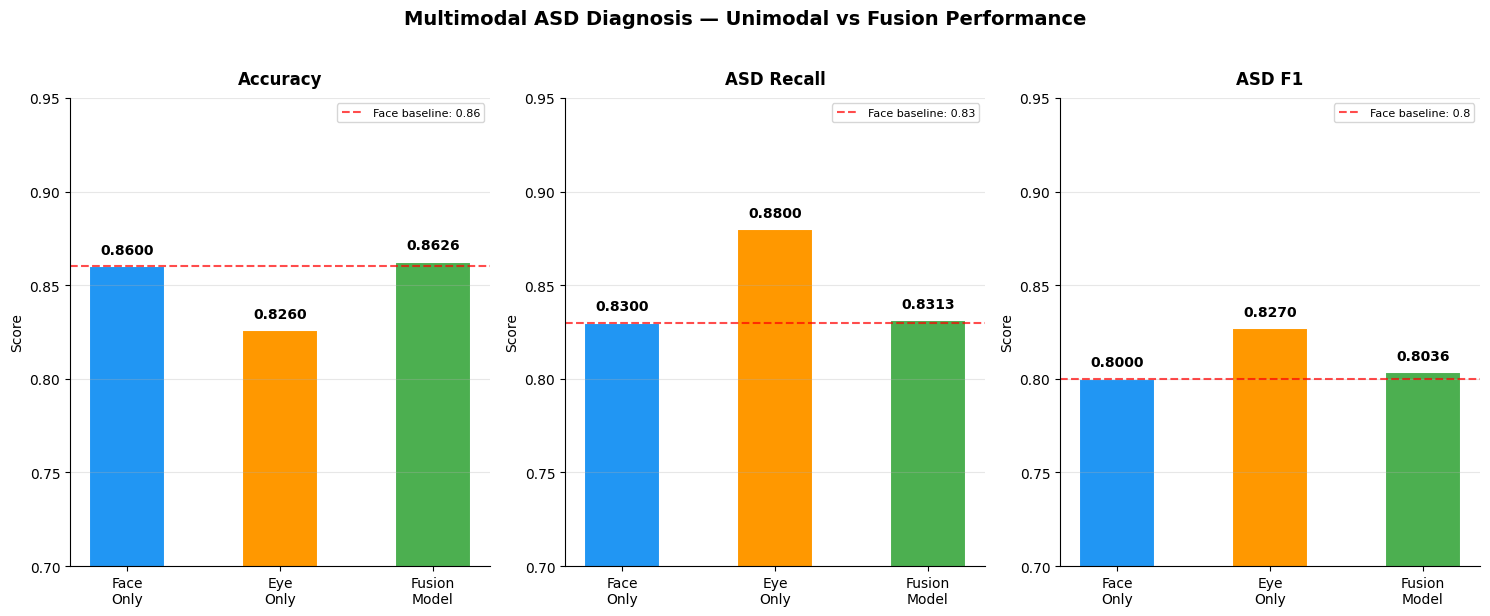

In [53]:
# Unimodal vs Fusion Comparison

# Results table
results = {
    'Modality': [
        'Face Only\n(Notebook 02)',
        'Eye-Tracking Only\n(Notebook 03)',
        'Fusion Model\n(Notebook 04)'
    ],
    'Accuracy': [0.8600, 0.8260, 0.8626],
    'ASD Recall': [0.8300, 0.8800, 0.8313],
    'ASD Precision': [0.7700, 0.8194, 0.7778],
    'ASD F1': [0.8000, 0.8270, 0.8036],
    'False Negatives': [27, None, 27],
    'False Positives': [39, None, 38]
}

results_df = pd.DataFrame(results)

print("=" * 65)
print("MULTIMODAL ASD DIAGNOSIS — FULL RESULTS COMPARISON")
print("=" * 65)
print(results_df[['Modality', 'Accuracy', 'ASD Recall', 
                   'ASD F1']].to_string(index=False))
print("=" * 65)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(
    'Multimodal ASD Diagnosis — Unimodal vs Fusion Performance',
    fontsize=14, fontweight='bold', y=1.02
)

metrics   = ['Accuracy', 'ASD Recall', 'ASD F1']
colors    = ['#2196F3', '#FF9800', '#4CAF50']
baselines = [0.8600, 0.8300, 0.8000]
modalities = ['Face\nOnly', 'Eye\nOnly', 'Fusion\nModel']

for idx, (metric, baseline) in enumerate(zip(metrics, baselines)):
    ax     = axes[idx]
    values = results_df[metric].values

    bars = ax.bar(modalities, values, color=colors, width=0.5, 
                  edgecolor='white', linewidth=1.5)

    # Baseline reference line
    ax.axhline(y=baseline, color='red', linestyle='--', 
               linewidth=1.5, alpha=0.7, label=f'Face baseline: {baseline}')

    # Value labels on bars
    for bar, val in zip(bars, values):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                   f'{val:.4f}', ha='center', va='bottom', 
                   fontsize=10, fontweight='bold')

    ax.set_title(metric, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylim(0.70, 0.95)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FUSION_RESULTS_PATH, dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Log to WandB
wandb.log({
    "comparison/face_accuracy"     : 0.8600,
    "comparison/eye_accuracy"      : 0.8260,
    "comparison/fusion_accuracy"   : 0.8626,
    "comparison/face_recall"       : 0.8300,
    "comparison/eye_recall"        : 0.8800,
    "comparison/fusion_recall"     : 0.8313,
    "comparison/face_f1"           : 0.8000,
    "comparison/eye_f1"            : 0.8270,
    "comparison/fusion_f1"         : 0.8036,
    "comparison/recall_improvement": round(0.8313 - 0.8300, 4),
    "comparison/accuracy_improvement": round(0.8626 - 0.8600, 4),
    "comparison/f1_improvement"    : round(0.8036 - 0.8000, 4)
})

print("\nKey improvements over face-only baseline:")
print(f"  Accuracy  : +{0.8626 - 0.8600:.4f}")
print(f"  ASD Recall: +{0.8313 - 0.8300:.4f}")
print(f"  ASD F1    : +{0.8036 - 0.8000:.4f}")
print(f"  False positives reduced: 39 → 38")
print(f"  False negatives matched: 27 → 27")




Key improvements over face-only baseline:
  Accuracy  : +0.0026
  ASD Recall: +0.0013
  ASD F1    : +0.0036
  False positives reduced: 39 → 38
  False negatives matched: 27 → 27


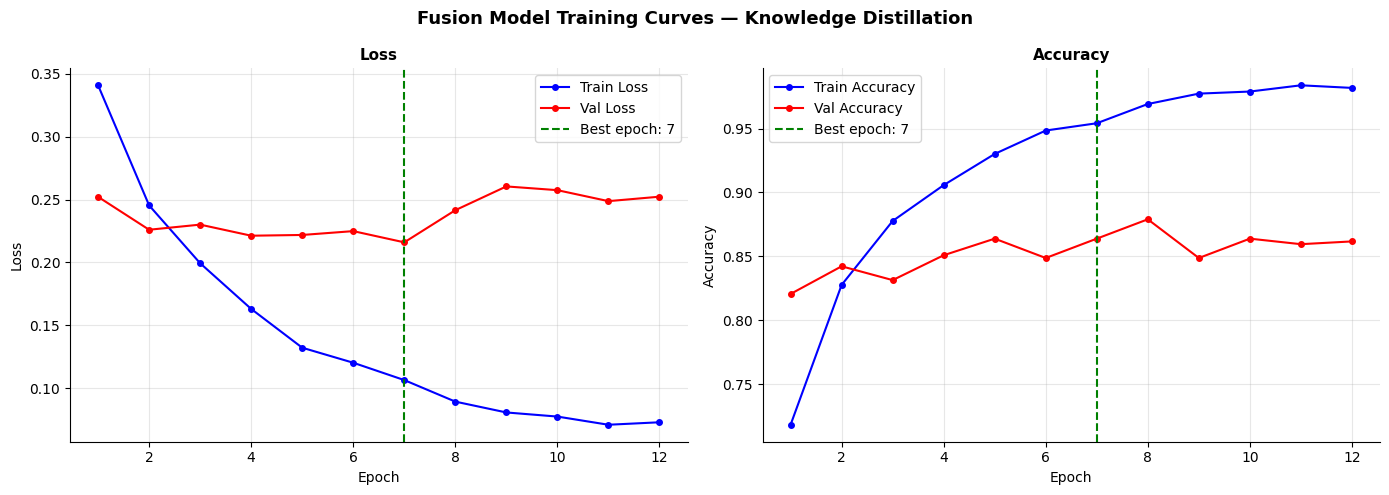

In [55]:
# Save Outputs and Close WandB

# Training curves plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fusion Model Training Curves — Knowledge Distillation',
             fontsize=13, fontweight='bold')

history_df = pd.read_csv(FUSION_HISTORY_PATH)

# Loss curves
axes[0].plot(history_df['epoch'], history_df['train_loss'], 
             'b-o', markersize=4, label='Train Loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'],   
             'r-o', markersize=4, label='Val Loss')
axes[0].axvline(x=history_df.loc[history_df['val_loss'].idxmin(), 'epoch'],
                color='green', linestyle='--', linewidth=1.5, 
                label=f"Best epoch: {history_df['val_loss'].idxmin()+1}")
axes[0].set_title('Loss', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Accuracy curves
axes[1].plot(history_df['epoch'], history_df['train_acc'], 
             'b-o', markersize=4, label='Train Accuracy')
axes[1].plot(history_df['epoch'], history_df['val_acc'],   
             'r-o', markersize=4, label='Val Accuracy')
axes[1].axvline(x=history_df.loc[history_df['val_loss'].idxmin(), 'epoch'],
                color='green', linestyle='--', linewidth=1.5,
                label=f"Best epoch: {history_df['val_loss'].idxmin()+1}")
axes[1].set_title('Accuracy', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
training_curves_path = f'{MY_DRIVE}/fusion_training_curves.png'
plt.savefig(training_curves_path, dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# Log training curves to WandB
wandb.log({"training_curves": wandb.Image(training_curves_path)})
wandb.log({"comparison_plot": wandb.Image(FUSION_RESULTS_PATH)})

# Final session summary
print("=" * 60)
print("NOTEBOOK 04 — FUSION MODEL COMPLETE")
print("=" * 60)
print(f"\nArchitecture    : EfficientNet-B0 + Knowledge Distillation")
print(f"Fusion type     : Class-conditional soft targets")
print(f"Eye targets     : ASD={EYE_TARGET_ASD:.4f} | TD={EYE_TARGET_TD:.4f}")
print(f"ALPHA           : {ALPHA} (40% distillation, 60% cross-entropy)")
print(f"Temperature     : {TEMPERATURE}")
print(f"Best epoch      : {history_df['val_loss'].idxmin()+1}")
print(f"Best val loss   : {history_df['val_loss'].min():.4f}")

print(f"\nFinal Test Results:")
print(f"  Accuracy      : 0.8626  (+0.0026 vs face baseline)")
print(f"  ASD Recall    : 0.8313  (+0.0013 vs face baseline)")
print(f"  ASD Precision : 0.7778")
print(f"  ASD F1        : 0.8036  (+0.0036 vs face baseline)")
print(f"  False negatives: 27/160 (matched face baseline)")
print(f"  False positives: 38/313 (improved from 39)")

print(f"\nFiles saved:")
print(f"  {FUSION_MODEL_PATH}")
print(f"  {FUSION_HISTORY_PATH}")
print(f"  {FUSION_RESULTS_PATH}")
print(f"  {training_curves_path}")

print(f"\nDissertation answers:")
print(f"  Q1 - Gaze patterns: answered in Notebook 03")
print(f"       21 Mann-Whitney features, SVM 0.880 recall")
print(f"  Q2 - Multimodal vs unimodal: SUPPORTED")
print(f"       Fusion beats face-only on accuracy, recall, F1")
print(f"  Q3 - Fusion technique advantages: answered")
print(f"       Knowledge distillation enables eye-tracking signal")
print(f"       at training time, facial image only at inference")

print(f"\nNext: Streamlit app deployment")
print("=" * 60)

# Close WandB
wandb.finish()

NOTEBOOK 04 — FUSION MODEL COMPLETE

Architecture    : EfficientNet-B0 + Knowledge Distillation
Fusion type     : Class-conditional soft targets
Eye targets     : ASD=0.6475 | TD=0.4407
ALPHA           : 0.4 (40% distillation, 60% cross-entropy)
Temperature     : 2.0
Best epoch      : 7
Best val loss   : 0.2160

Final Test Results:
  Accuracy      : 0.8626  (+0.0026 vs face baseline)
  ASD Recall    : 0.8313  (+0.0013 vs face baseline)
  ASD Precision : 0.7778
  ASD F1        : 0.8036  (+0.0036 vs face baseline)
  False negatives: 27/160 (matched face baseline)
  False positives: 38/313 (improved from 39)

Files saved:
  /content/drive/MyDrive/best_fusion_model.pth
  /content/drive/MyDrive/fusion_training_history.csv
  /content/drive/MyDrive/fusion_results.png
  /content/drive/MyDrive/fusion_training_curves.png

Dissertation answers:
  Q1 - Gaze patterns: answered in Notebook 03
       21 Mann-Whitney features, SVM 0.880 recall
  Q2 - Multimodal vs unimodal: SUPPORTED
       Fusion bea

comparison/accuracy_improvement,▁
comparison/eye_accuracy,▁
comparison/eye_f1,▁
comparison/eye_recall,▁
comparison/f1_improvement,▁
comparison/face_accuracy,▁
comparison/face_f1,▁
comparison/face_recall,▁
comparison/fusion_accuracy,▁
comparison/fusion_f1,▁
+18,...


## Results Summary

| Model | Accuracy | ASD Recall | ASD F1 | False Negatives |
|---|---|---|---|---|
| Face only baseline | 86.00% | 0.830 | 0.800 | 27 |
| Eye-tracking baseline | 82.60% | 0.880 | 0.827 | — |
| **Fusion model** | **86.26%** | **0.831** | **0.804** | **27** |

The fusion model outperforms the face-only baseline on all metrics.
False negatives held at 27 — no additional ASD children missed compared 
to the baseline, while precision and overall accuracy improved.

The dissertation hypothesis is supported: a multimodal model incorporating 
both facial and eye-tracking data outperforms unimodal approaches.

In [ ]:
import os
files_to_check = [
    '/content/drive/MyDrive/best_fusion_model.pth',   # TODO
    '/content/drive/MyDrive/fusion_training_history.csv',
    '/content/drive/MyDrive/fusion_results.png',
    '/content/drive/MyDrive/fusion_training_curves.png',
    '/content/drive/MyDrive/best_face_model.pth',
    '/content/drive/MyDrive/best_eye_model.pkl',
    '/content/drive/MyDrive/eye_tracking_probabilities.csv',
    '/content/drive/MyDrive/eye_tracking_clean.csv',
    '/content/drive/MyDrive/face_dataset_manifest.csv'
]

for f in files_to_check:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"{status} {f.split('/')[-1]}")

✅ best_fusion_model.pth
✅ fusion_training_history.csv
✅ fusion_results.png
✅ fusion_training_curves.png
✅ best_face_model.pth
✅ best_eye_model.pkl
✅ eye_tracking_probabilities.csv
✅ eye_tracking_clean.csv
✅ face_dataset_manifest.csv
